In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Defining Functions

In [2]:
# function to get the basic info about the dataset
def visual_data(df, hist_plot=True, corr_plot=True, multicollinear=True, corr_threshold=0.80):
    # basic info
    print("Data Information:")
    df.info()
    
    # first 10 rows
    print("\nFirst 10 rows:")
    print(df[:10])
    
    # duplicates
    duplicate_count = df.duplicated().sum()
    duplicate_percentage = (duplicate_count / len(df)) * 100
    print(f"\nDuplicate Rows: {duplicate_count} ({duplicate_percentage:.2f}% of total rows)")

    # missing values
    missing_percentage = (df.isna().mean() * 100).round(2)
    total_missing = missing_percentage.sum()
    if total_missing > 0:
        print("\nMissing Values (%):")
        print(missing_percentage[missing_percentage > 0].sort_values(ascending=False))
    else:
        print(f"\nMissing Values: 0.00%")
    
    # descriptive statistics for numeric columns
    print("\nDescriptive Statistics (Numerical):")
    print(df.describe().T.round(2))

    # descriptive statistics for categorical columns
    categorical_cols = df.select_dtypes(include=['object', 'category'])
    print("\nDescriptive Statistics (Categorical):")
    print(categorical_cols.describe().T)

    # histogram
    if hist_plot:
        df.hist(bins=20, color='blue', edgecolor='black', 
        grid=False,figsize=(12, 8))
        plt.tight_layout()
        plt.show()
    
    # correlation heatmap
    if corr_plot:
        numeric_cols = df.select_dtypes(include=['number'])
        plt.figure(figsize=(8, 6))
        corr_matrix = numeric_cols.corr()
        sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', 
        fmt='.2f', linewidths=0.5)
        plt.title('Correlation Matrix')
        plt.show()

    # multicollinearity
    if multicollinear and not numeric_cols.empty:
        print("\nChecking for Multicollinearity (Correlation Threshold > {:.2f}):".format(corr_threshold))
        high_corr_pairs = []
        corr_matrix = numeric_cols.corr().abs()  # Calculate correlation matrix for numeric columns only
        for i in range(len(corr_matrix.columns)):
            for j in range(i):
                if corr_matrix.iloc[i, j] > corr_threshold:
                    high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))
        
        if high_corr_pairs:
            print("High correlation pairs found:")
            for pair in high_corr_pairs:
                print(f" - {pair[0]} and {pair[1]}: Correlation = {pair[2]:.2f}")
        else:
            print("No highly correlated pairs found.")

    return df

In [3]:
# function that defines who appears before and after Hume's Warbler (target specie) within 3 seconds window
def birds_around(df, name="hume's warbler", window=3):
    # Filter for events matching the target common name
    events = df[df['Common name'] == name]
    output_rows = []
    
    for _, event in events.iterrows():
        # Define the time window masks for "before" and "after"
        before_mask = (
            (df['Start (s)'] >= event['Start (s)'] - window) &
            (df['End (s)'] <= event['Start (s)'])
        )
        after_mask = (
            (df['Start (s)'] >= event['End (s)']) &
            (df['End (s)'] <= event['End (s)'] + window)
        )
        
        # Process birds before the event
        birds_before = df[before_mask]
        for _, bird in birds_before.iterrows():
            row = bird.to_dict()
            row.update({
                'Event_Start': event['Start (s)'],
                'Event_End': event['End (s)'],
                'Window': 'Before'
            })
            output_rows.append(row)
        
        # Process birds after the event
        birds_after = df[after_mask]
        for _, bird in birds_after.iterrows():
            row = bird.to_dict()
            row.update({
                'Event_Start': event['Start (s)'],
                'Event_End': event['End (s)'],
                'Window': 'After'
            })
            output_rows.append(row)
    
    result_df = pd.DataFrame(output_rows).drop_duplicates().reset_index(drop=True)
    return result_df


In [4]:
# merging cocontiguous intervals for rows with the same 'Scientific/Common name'

def merge_contiguous_intervals(df):

    # Initialize the list to collect merged rows
    merged_rows = []
    
    # Start with the first row as the current interval
    current = df.iloc[0].copy()
    
    # Iterate over the DataFrame from the second row onward
    for idx in range(1, len(df)):
        row = df.iloc[idx]
        
        # If the same species and the intervals are contiguous, merge them
        if (row['Common name'] == current['Common name'] and 
            row['Start (s)'] == current['End (s)']):
            # Extend the current interval's end time
            current['End (s)'] = row['End (s)']
        else:
            # Append the current interval and start a new one
            merged_rows.append(current)
            current = row.copy()
    

    merged_rows.append(current)
    
    merged_df = pd.DataFrame(merged_rows)
    
    # Remove rows with a 3-second interval (i.e., where duration equals 3 seconds)
    merged_df = merged_df[(merged_df['End (s)'] - merged_df['Start (s)']) != 3]
    
    # Reset the index of the final DataFrame
    merged_df = merged_df.reset_index(drop=True)
    
    return merged_df




In [5]:
# function to explore the dataset
# This function prints out unique values and their counts for each column in the DataFrame.
def explore_dataset(df):
    for column in df.columns:
        print(f"Column: {column}")
        print("Unique values:")
        print(df[column].unique())
        print("\nValue counts:")
        print(round(df[column].value_counts(normalize=True) * 100, 2))
        print("-" * 40)

In [6]:
# function to calculate the accuracy of the dataset by calculating the mean confidence score
def accuracy(data):
    accuracy = data['Confidence'].mean().round(3)
    accuracy_habitant = data[data['Habitant'] == 1]['Confidence'].mean().round(3)
    accuracy__non_habitant = data[data['Habitant'] == 0]['Confidence'].mean().round(3)

    print('Total accuracy:' , accuracy)
    print('Habitant accuracy:' , accuracy_habitant)
    print('Non Habitant accuracy:' , accuracy__non_habitant)
    print('_ ' *40)

In [7]:
# function to filter the dataset by groups
# based on the combination of 'ID', 'Month', 'Day', and 'Time', 'Start' and 'End' columns  
def filter_dataset_by_groups(df):
    # Create the temporary column 'Temp_ID' by concatenating the 6 columns as strings
    df['Temp_ID'] = (
        df['ID'].astype(str) + '_' +
        df['Month'].astype(str) + '_' +
        df['Day'].astype(str) + '_' +
        df['Time'].astype(str) + '_' +
        df['Start (s)'].astype(str) + '_' +
        df['End (s)'].astype(str)
    )
    
    # Filter the dataframe to include only groups with more than one row.
    # This will drop rows that are the only instance in their group.
    filtered_df = df.groupby('Temp_ID').filter(lambda group: len(group) > 1).reset_index(drop=True)
    
    return filtered_df

Preprocessing Data

In [8]:
data = pd.read_csv('data/data.csv')

In [9]:
# dropping redundant columns
data = data.drop(columns=['Unnamed: 0', 'Scientific name', 'Year'])

# split the dataset into different subsets
data_05 = data
data_06 = data[data['Confidence'] >= 0.6]
data_07 = data[data['Confidence'] >= 0.7]
data_08 = data[data['Confidence'] >= 0.8]
data_09 = data[data['Confidence'] >= 0.9]

In [10]:
print('data_05')
accuracy(data_05)
print('data_05')
accuracy(data_06)
print('data_07')
accuracy(data_07)
print('data_08')
accuracy(data_08)
print('data_09')
accuracy(data_09)


data_05
Total accuracy: 0.756
Habitant accuracy: 0.77
Non Habitant accuracy: 0.697
_ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ 
data_05
Total accuracy: 0.815
Habitant accuracy: 0.823
Non Habitant accuracy: 0.772
_ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ 
data_07
Total accuracy: 0.866
Habitant accuracy: 0.871
Non Habitant accuracy: 0.837
_ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ 
data_08
Total accuracy: 0.913
Habitant accuracy: 0.915
Non Habitant accuracy: 0.899
_ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ 
data_09
Total accuracy: 0.957
Habitant accuracy: 0.957
Non Habitant accuracy: 0.953
_ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ 


Plot Total, Habitant and Non Habitant observations by confidence levels

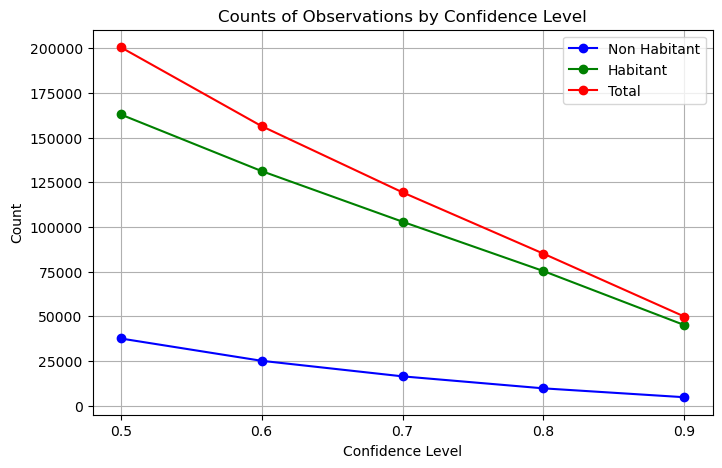

In [11]:
# Define confidence levels and corresponding datasets
datasets = ['0.5', '0.6', '0.7', '0.8', '0.9']

# Extract counts for values 0 and 1 for each dataset
counts_0 = [x['Habitant'].value_counts().get(0, 0) for x in [data_05, data_06, data_07, data_08, data_09]]
counts_1 = [x['Habitant'].value_counts().get(1, 0) for x in [data_05, data_06, data_07, data_08, data_09]]

# Compute total observations counts for each dataset
total_counts = [len(data_05), len(data_06), len(data_07), len(data_08), len(data_09)]

# Define x-axis positions
x = range(len(datasets))

plt.figure(figsize=(8, 5))
plt.plot(x, counts_0, marker='o', linestyle='-', color = 'blue', label='Non Habitant')
plt.plot(x, counts_1, marker='o', linestyle='-', color = 'green', label='Habitant')
plt.plot(x, total_counts, marker='o', linestyle='-', color = 'red', label='Total')

plt.xticks(x, datasets)
plt.xlabel("Confidence Level")
plt.ylabel("Count")
plt.title("Counts of Observations by Confidence Level")
plt.legend()
plt.grid(True)
plt.show()


In [12]:
print(counts_0)
print(counts_1)
print(total_counts)


[37629, 25143, 16441, 9728, 4762]
[162979, 131306, 102968, 75362, 45133]
[200608, 156449, 119409, 85090, 49895]


Calculate absolute and relative differences between consecutive confidence levels

In [13]:
# Non Habitant
abs_0 = np.diff(counts_0) # Absolute difference
rel_0 = (np.diff(counts_0) / counts_0[:-1] * 100).round(2) # Relative differences: (current - previous) / previous * 100

print("Absolute differences, Non Habitant:", abs_0)
print("Relative differences (%), Non Habitant:", rel_0)

Absolute differences, Non Habitant: [-12486  -8702  -6713  -4966]
Relative differences (%), Non Habitant: [-33.18 -34.61 -40.83 -51.05]


In [14]:
# Habitant
abs_1 = np.diff(counts_1)
rel_1 = (np.diff(counts_1) / counts_1[:-1] * 100).round(2)

print("Absolute differences, Habitant:", abs_1)
print("Relative differences (%), Habitant:", rel_1)

Absolute differences, Habitant: [-31673 -28338 -27606 -30229]
Relative differences (%), Habitant: [-19.43 -21.58 -26.81 -40.11]


In [15]:
# Total
abs_total = np.diff(total_counts)
rel_total = (np.diff(total_counts) / total_counts[:-1] * 100).round(2)

print("Absolute differences:", abs_total)
print("Relative differences (%):", rel_total)

Absolute differences: [-44159 -37040 -34319 -35195]
Relative differences (%): [-22.01 -23.68 -28.74 -41.36]


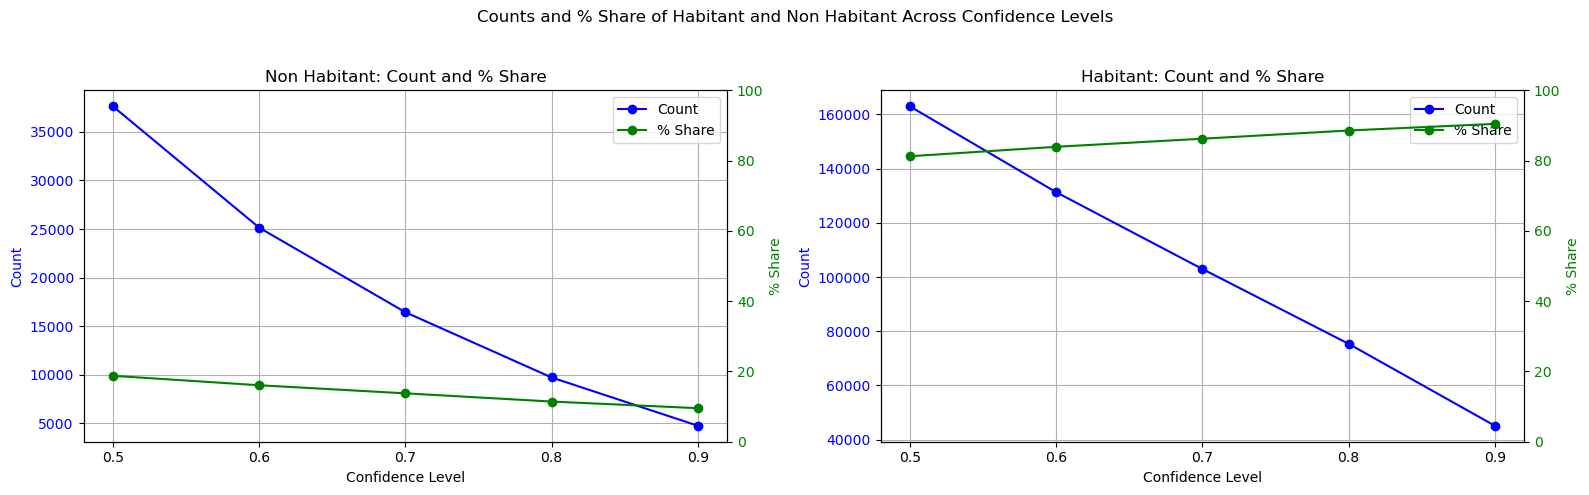

In [16]:

datasets = ['0.5', '0.6', '0.7', '0.8', '0.9']
x = range(len(datasets))

# Compute counts and percentages for Habitants 0 and 1
counts_0 = [x['Habitant'].value_counts().get(0, 0) for x in [data_05, data_06, data_07, data_08, data_09]]
percentage_0 = [x['Habitant'].value_counts(normalize=True).get(0, 0) * 100 for x in [data_05, data_06, data_07, data_08, data_09]]

counts_1 = [x['Habitant'].value_counts().get(1, 0) for x in [data_05, data_06, data_07, data_08, data_09]]
percentage_1 = [x['Habitant'].value_counts(normalize=True).get(1, 0) * 100 for x in [data_05, data_06, data_07, data_08, data_09]]

# Create a figure with two subplots side by side
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(16, 5))

# Non Habitant
ax_left.plot(x, counts_0, marker='o', linestyle='-', color = 'blue', label='Count')
ax_left.set_xlabel("Confidence Level")
ax_left.set_ylabel("Count", color = 'blue')
ax_left.tick_params(axis='y', labelcolor='blue')
ax_left.set_xticks(x)
ax_left.set_xticklabels(datasets)
ax_left.grid(True)
ax_left.set_title("Non Habitant: Count and % Share")

# Create a twin y-axis for percentage on the left subplot
ax_left_twin = ax_left.twinx()
ax_left_twin.plot(x, percentage_0, marker='o', linestyle='-', color='green', label='% Share')
ax_left_twin.set_ylabel("% Share", color ='green')
ax_left_twin.tick_params(axis='y', labelcolor='green')
ax_left_twin.set_ylim(0, 100)

# Combine legends for the left subplot
lines_left, labels_left = ax_left.get_legend_handles_labels()
lines_left_twin, labels_left_twin = ax_left_twin.get_legend_handles_labels()
ax_left.legend(lines_left + lines_left_twin, labels_left + labels_left_twin, loc='best')

# Habitant
ax_right.plot(x, counts_1, marker='o', linestyle='-', color = 'blue', label='Count')
ax_right.set_xlabel("Confidence Level")
ax_right.set_ylabel("Count", color = 'blue')
ax_right.tick_params(axis='y', labelcolor='blue')
ax_right.set_xticks(x)
ax_right.set_xticklabels(datasets)
ax_right.grid(True)
ax_right.set_title("Habitant: Count and % Share")

# Create a twin y-axis for percentage on the right subplot
ax_right_twin = ax_right.twinx()
ax_right_twin.plot(x, percentage_1, marker='o', linestyle='-', color='green', label='% Share')
ax_right_twin.set_ylabel("% Share", color ='green')
ax_right_twin.tick_params(axis='y', labelcolor='green')
ax_right_twin.set_ylim(0, 100)

# Combine legends for the right subplot
lines_right, labels_right = ax_right.get_legend_handles_labels()
lines_right_twin, labels_right_twin = ax_right_twin.get_legend_handles_labels()
ax_right.legend(lines_right + lines_right_twin, labels_right + labels_right_twin, loc='best')

# Add a main title and adjust layout
plt.suptitle("Counts and % Share of Habitant and Non Habitant Across Confidence Levels")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()



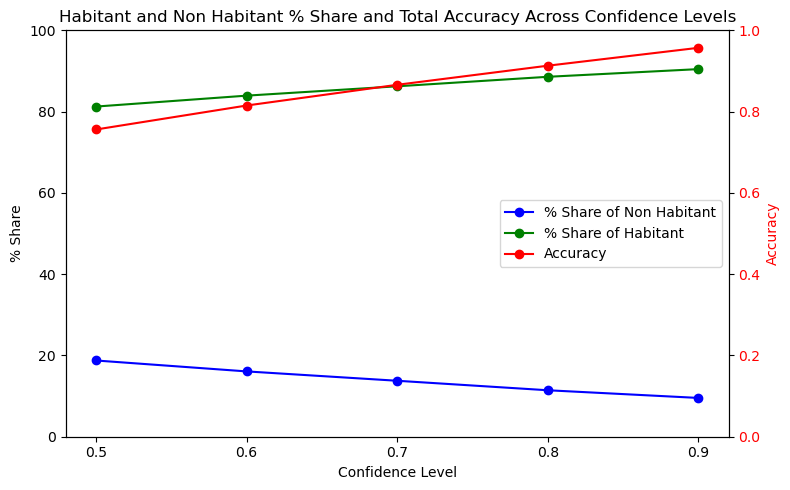

In [17]:

# Compute accuracies (mean of 'Confidence') for each dataset
accuracies = [
    data_05['Confidence'].mean().round(3),
    data_06['Confidence'].mean().round(3),
    data_07['Confidence'].mean().round(3),
    data_08['Confidence'].mean().round(3),
    data_09['Confidence'].mean().round(3)
]

# Create one figure with twin y-axes
fig, ax1 = plt.subplots(figsize=(8, 5))

# Primary axis: plot percentages for Habitant 0 and  1
line0, = ax1.plot(x, percentage_0, marker='o', linestyle='-', color='blue', label='% Share of Non Habitant')
line1, = ax1.plot(x, percentage_1, marker='o', linestyle='-', color='green', label='% Share of Habitant')
ax1.set_xlabel("Confidence Level")
ax1.set_xticks(x)
ax1.set_xticklabels(datasets)
ax1.set_ylabel("% Share", color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.set_ylim(0, 100)

# Secondary axis: plot Accuracy
ax2 = ax1.twinx()
line2, = ax2.plot(x, accuracies, marker='o', linestyle='-', color='red', label='Accuracy')
ax2.set_ylabel("Accuracy", color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 1)

# Combine legends from both axes
lines = [line0, line1, line2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='best')

plt.title("Habitant and Non Habitant % Share and Total Accuracy Across Confidence Levels")
plt.tight_layout()
plt.show()


In [18]:
print('Accuracy at Confidence 0.7: ', data_07['Confidence'].mean().round(3))
print(data_07['Habitant'].value_counts(normalize=True).round(2))


Accuracy at Confidence 0.7:  0.866
Habitant
1    0.86
0    0.14
Name: proportion, dtype: float64


In [19]:
accuracies

[0.756, 0.815, 0.866, 0.913, 0.957]

Total dataset accuracy is very equal to % share of habitants at confidence level 0.7

Exploratory Data Analysis

In [20]:
df = data_07

In [21]:
df = df[df['Habitant'] == 1].reset_index(drop=True)

Data Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102968 entries, 0 to 102967
Data columns (total 12 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Start (s)    102968 non-null  float64
 1   End (s)      102968 non-null  float64
 2   Common name  102968 non-null  object 
 3   Confidence   102968 non-null  float64
 4   ID           102968 non-null  object 
 5   Month        102968 non-null  int64  
 6   Day          102968 non-null  int64  
 7   Time         102968 non-null  int64  
 8   Latitude     102968 non-null  float64
 9   Longitude    102968 non-null  float64
 10  Elevation    102968 non-null  int64  
 11  Habitant     102968 non-null  int64  
dtypes: float64(5), int64(5), object(2)
memory usage: 9.4+ MB

First 10 rows:
   Start (s)  End (s)     Common name  Confidence     ID  Month  Day  Time  \
0        6.0      9.0  hume's warbler      0.8799  psh10      6    4     6   
1       27.0     30.0  hume's warbl

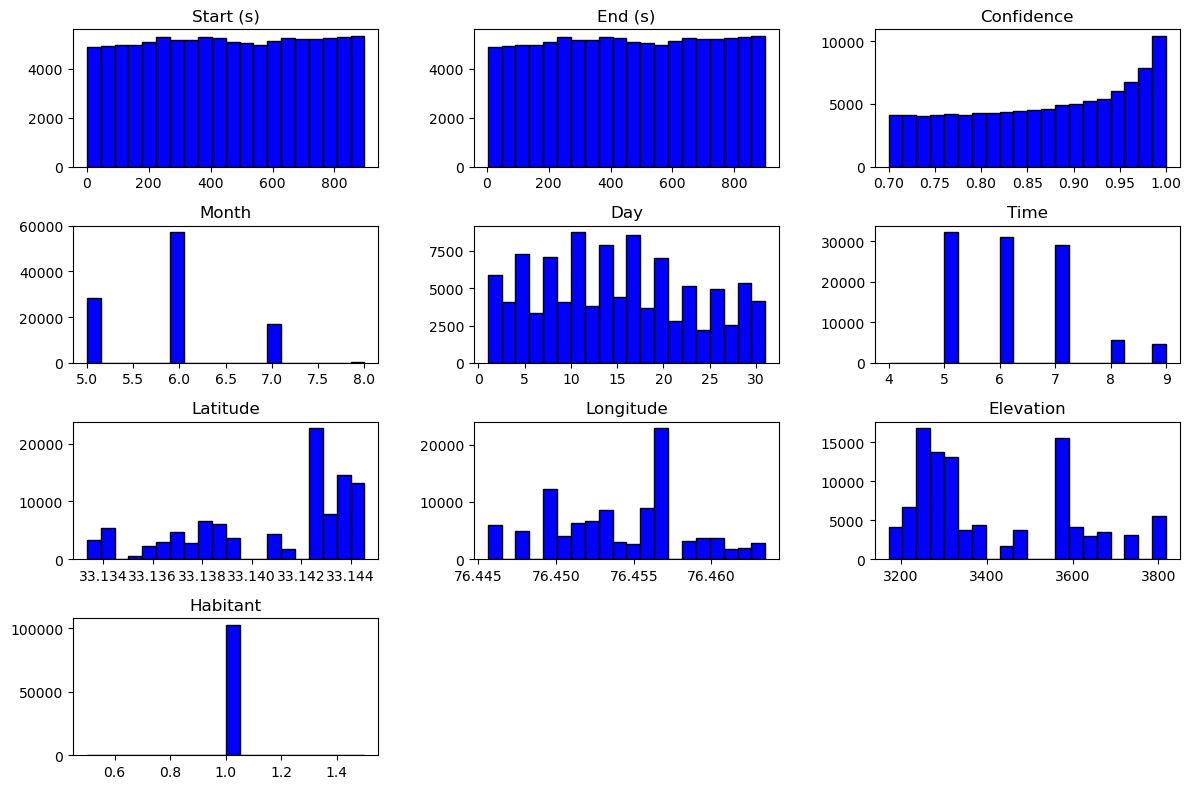

c:\Users\shang\Programs\anaconda3\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


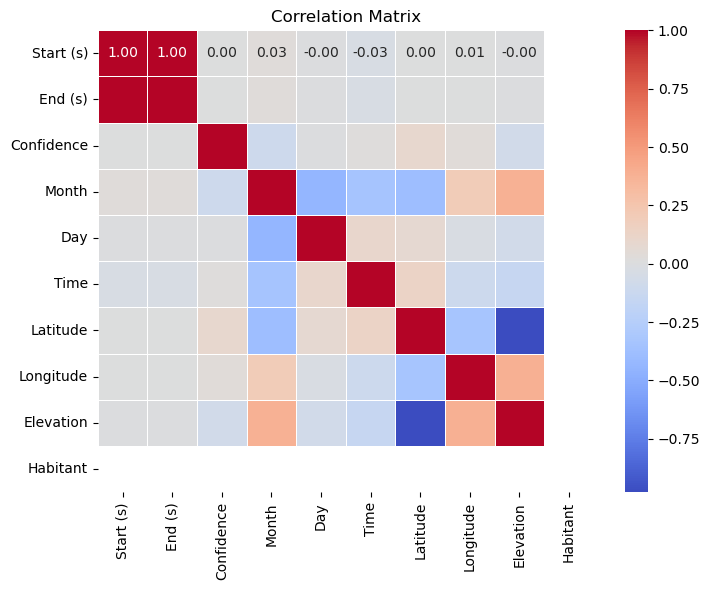


Checking for Multicollinearity (Correlation Threshold > 0.80):
High correlation pairs found:
 - End (s) and Start (s): Correlation = 1.00
 - Elevation and Latitude: Correlation = 0.98


,Start (s),End (s),Common name,Confidence,ID,Month,Day,Time,Latitude,Longitude,Elevation,Habitant
0,6.0,9.0,hume's warbler,0.8799,psh10,6,4,6,33.135140,76.463139,3664,1
1,27.0,30.0,hume's warbler,0.8052,psh10,6,4,6,33.135140,76.463139,3664,1
2,39.0,42.0,hume's warbler,0.8985,psh10,6,4,6,33.135140,76.463139,3664,1
3,54.0,57.0,hume's warbler,0.7435,psh10,6,4,6,33.135140,76.463139,3664,1
4,60.0,63.0,hume's warbler,0.8016,psh10,6,4,6,33.135140,76.463139,3664,1
...,...,...,...,...,...,...,...,...,...,...,...,...
102963,54.0,57.0,variegated laughingthrush,0.8373,psm9,7,26,7,33.141258,76.461078,3438,1
102964,66.0,69.0,variegated laughingthrush,0.7415,psm9,7,26,7,33.141258,76.461078,3438,1
102965,72.0,75.0,variegated laughingthrush,0.8791,psm9,7,26,7,33.141258,76.461078,3438,1
102966,81.0,84.0,variegated laughingthrush,0.7492,psm9,7,26,7,33.141258,76.461078,3438,1


In [22]:
visual_data(df)

In [23]:
explore_dataset(df)

Column: Start (s)
Unique values:
[  6.  27.  39.  54.  60.  69.  75.  87.  93.  99. 123. 129. 135. 153.
 159. 165. 174. 180. 201. 213. 219. 225. 231. 240. 255. 261. 273. 282.
 288. 297. 300. 306. 321. 330. 351. 357. 378. 387. 411. 414. 456. 471.
 486. 501. 507. 516. 525. 534. 543. 546. 558. 561. 570. 573. 582. 597.
 606. 612. 615. 621. 627. 636. 642. 648. 663. 672. 681. 690. 699. 705.
 711. 720. 729. 738. 744. 753. 765. 774. 786. 795. 804. 813. 819. 828.
 837. 846. 855. 861. 867. 876.  12.  81. 234. 360. 492. 495. 594. 624.
 645. 657. 675. 696. 726. 762. 768. 777. 783. 789. 825. 831.  21.  45.
  48. 192. 198. 204. 285. 339. 429. 474. 510. 600. 885.  51. 150. 186.
 195. 216. 222. 228. 249. 276. 420. 423. 432. 603. 666. 171. 183. 189.
 210. 270. 366. 834. 849. 870. 879.  63.  84. 138. 156. 309. 489. 531.
 555. 147. 279. 342. 348. 369. 375. 435. 447. 462. 654. 660. 678. 723.
 759.  66. 639. 741.   9.  78. 111. 891. 702. 105. 108. 177. 264. 438.
 549. 567. 426. 498. 792. 801. 816. 873.  15

Exploring the songs ( continuos intervals > 3 sec of the same specie)

In [24]:
df_song = merge_contiguous_intervals(df)

In [25]:
df_song.to_csv('data/songs.csv')

Data Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15342 entries, 0 to 15341
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Start (s)    15342 non-null  float64
 1   End (s)      15342 non-null  float64
 2   Common name  15342 non-null  object 
 3   Confidence   15342 non-null  float64
 4   ID           15342 non-null  object 
 5   Month        15342 non-null  int64  
 6   Day          15342 non-null  int64  
 7   Time         15342 non-null  int64  
 8   Latitude     15342 non-null  float64
 9   Longitude    15342 non-null  float64
 10  Elevation    15342 non-null  int64  
 11  Habitant     15342 non-null  int64  
dtypes: float64(5), int64(5), object(2)
memory usage: 1.4+ MB

First 10 rows:
   Start (s)  End (s)                Common name  Confidence     ID  Month  \
0      297.0    303.0             hume's warbler      0.7926  psh10      6   
1      411.0    417.0         himalayan bluetail   

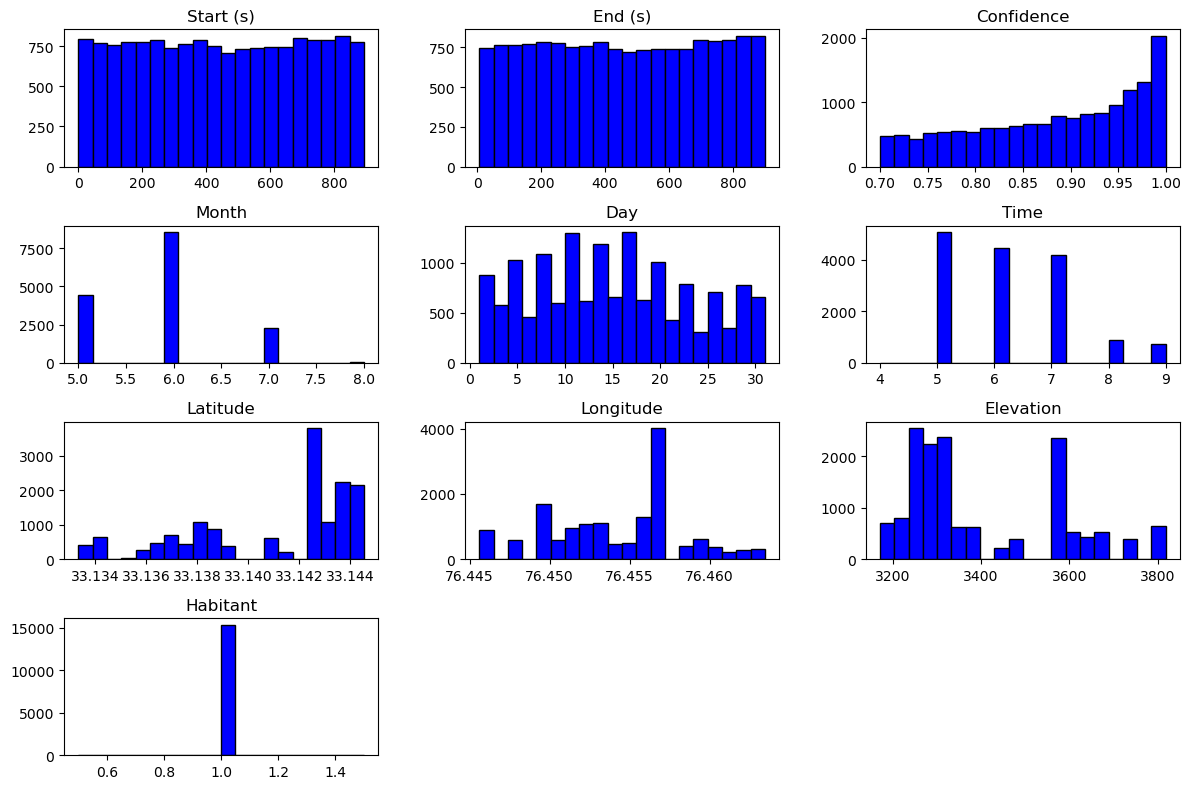

c:\Users\shang\Programs\anaconda3\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


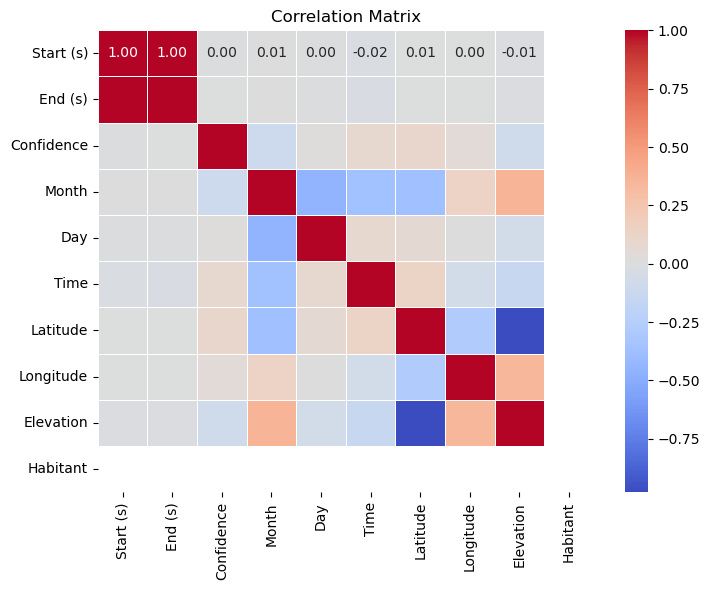


Checking for Multicollinearity (Correlation Threshold > 0.80):
High correlation pairs found:
 - End (s) and Start (s): Correlation = 1.00
 - Elevation and Latitude: Correlation = 0.98


,Start (s),End (s),Common name,Confidence,ID,Month,Day,Time,Latitude,Longitude,Elevation,Habitant
0,297.0,303.0,hume's warbler,0.7926,psh10,6,4,6,33.135140,76.463139,3664,1
1,411.0,417.0,himalayan bluetail,0.8589,psh10,6,4,6,33.135140,76.463139,3664,1
2,543.0,549.0,hume's warbler,0.8678,psh10,6,4,6,33.135140,76.463139,3664,1
3,612.0,618.0,hume's warbler,0.7650,psh10,6,4,6,33.135140,76.463139,3664,1
4,45.0,51.0,buff-barred warbler,0.7300,psh10,6,5,5,33.135140,76.463139,3664,1
...,...,...,...,...,...,...,...,...,...,...,...,...
15337,633.0,639.0,variegated laughingthrush,0.8825,psm9,7,24,7,33.141258,76.461078,3438,1
15338,660.0,672.0,variegated laughingthrush,0.8735,psm9,7,24,7,33.141258,76.461078,3438,1
15339,693.0,699.0,variegated laughingthrush,0.9726,psm9,7,24,7,33.141258,76.461078,3438,1
15340,102.0,108.0,himalayan bluetail,0.9987,psm9,7,25,7,33.141258,76.461078,3438,1


In [26]:
visual_data(df_song)

In [33]:
explore_dataset(df_song)

Column: Start (s)
Unique values:
[297. 411. 543. 612.  45. 192. 201. 213. 420.  81. 531. 375. 432. 621.
 720. 105.  42.  54. 204. 834. 882. 462. 501. 555. 570. 591. 609.  66.
 585. 789. 819. 129. 246. 345. 513. 228. 441. 813. 507.   6.  18.  27.
 669. 717. 759. 801.  12.  21.  51.  60.  69.  90.  99. 111. 120. 147.
 159. 231. 249. 267. 387.  75. 315. 753. 795. 843. 858.  15. 198. 402.
 414. 429. 438. 846. 876. 891. 477. 492. 525. 564. 588. 606. 639. 648.
 657. 666. 693. 714. 885.   9. 243. 336. 348. 357. 366. 378. 390. 408.
 600. 852.   3.  48.  78. 102. 138. 342. 633. 732. 210. 222. 417. 450.
 528. 567. 582. 645. 675. 711. 273. 300. 318. 456. 597. 186. 708. 726.
   0. 207. 240. 561. 618. 144. 699. 744. 261. 351. 255. 288. 294. 363.
 156. 180. 258. 651. 495. 540. 756. 783. 822.  84.  93. 594. 828. 135.
 177. 276. 678. 816. 168. 423. 459. 132. 141. 150. 165. 354. 393. 489.
 627. 660. 780. 855. 870. 468. 384. 396. 435. 444. 480. 576. 831. 183.
 723. 735. 486. 237.  33. 219.  24. 117. 360

Explore who is signing 3 sec before and after Hume's Warbler

In [ ]:
# df_birds_3 = birds_around(df)
# df_birds_3.to_csv('data/birds_around_3.csv')

Data Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205277 entries, 0 to 205276
Data columns (total 16 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Start (s)    205277 non-null  float64
 1   End (s)      205277 non-null  float64
 2   Common name  205277 non-null  object 
 3   Confidence   205277 non-null  float64
 4   ID           205277 non-null  object 
 5   Month        205277 non-null  int64  
 6   Day          205277 non-null  int64  
 7   Time         205277 non-null  int64  
 8   Latitude     205277 non-null  float64
 9   Longitude    205277 non-null  float64
 10  Elevation    205277 non-null  int64  
 11  Habitant     205277 non-null  int64  
 12  Temp_ID      205277 non-null  object 
 13  Event_Start  205277 non-null  float64
 14  Event_End    205277 non-null  float64
 15  Window       205277 non-null  object 
dtypes: float64(7), int64(5), object(4)
memory usage: 25.1+ MB

First 10 rows:
   Start (s)  End 

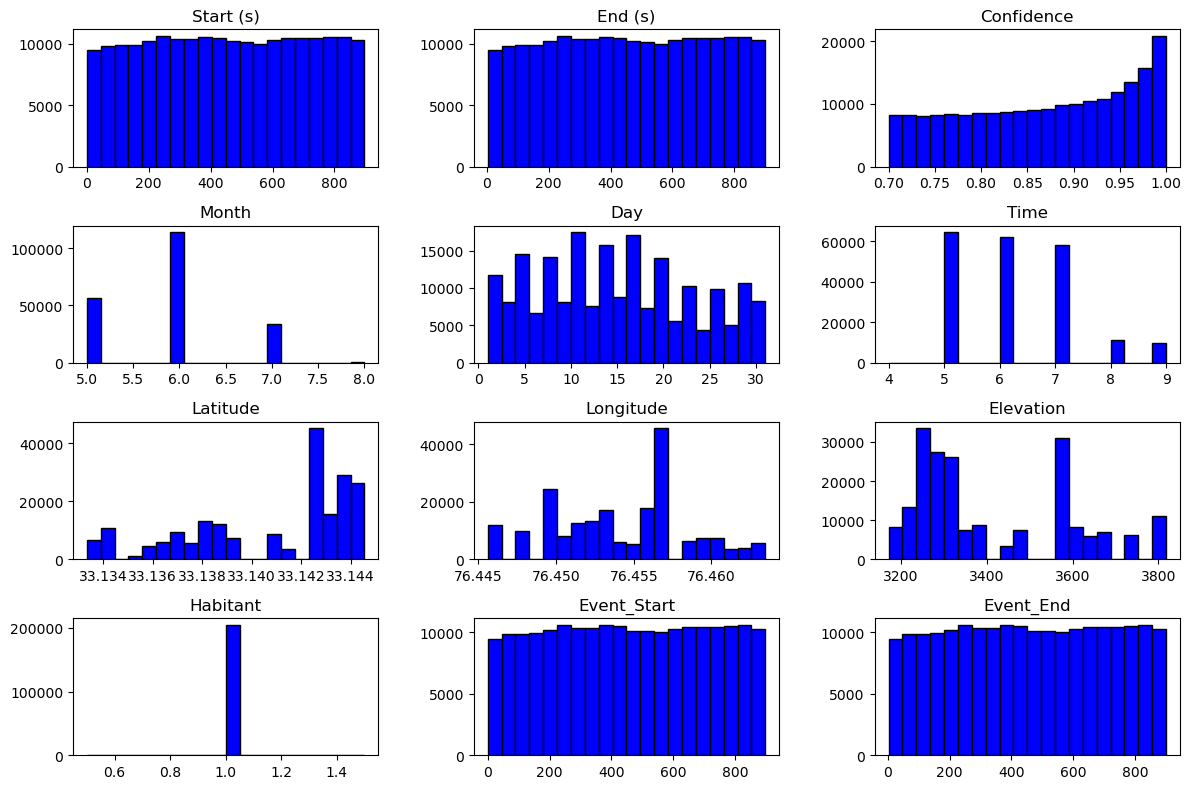

c:\Users\shang\Programs\anaconda3\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


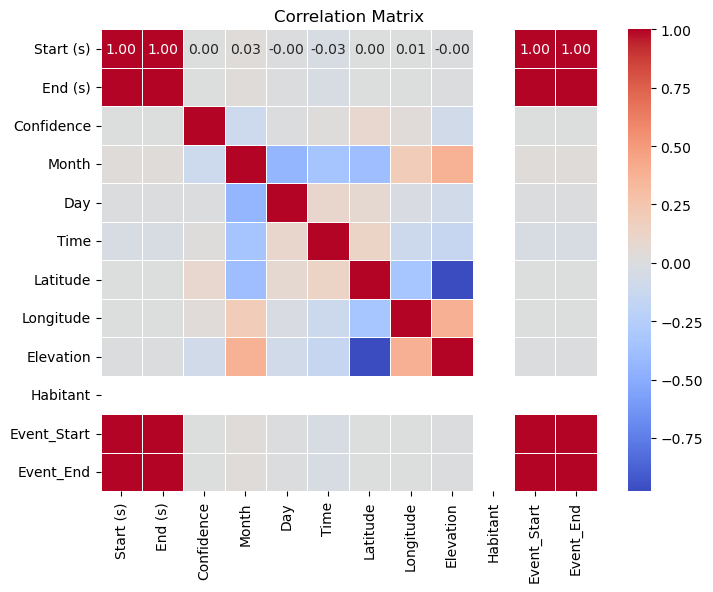


Checking for Multicollinearity (Correlation Threshold > 0.80):
High correlation pairs found:
 - End (s) and Start (s): Correlation = 1.00
 - Elevation and Latitude: Correlation = 0.98
 - Event_Start and Start (s): Correlation = 1.00
 - Event_Start and End (s): Correlation = 1.00
 - Event_End and Start (s): Correlation = 1.00
 - Event_End and End (s): Correlation = 1.00
 - Event_End and Event_Start: Correlation = 1.00


,Start (s),End (s),Common name,Confidence,ID,Month,Day,Time,Latitude,Longitude,Elevation,Habitant,Temp_ID,Event_Start,Event_End,Window
0,3.0,6.0,himalayan bluetail,0.8521,psh2,6,5,7,33.133459,76.450725,3794,1,psh2_6_5_7_3.0_6.0,6.0,9.0,Before
1,3.0,6.0,variegated laughingthrush,0.9137,psh2,6,8,6,33.133459,76.450725,3794,1,psh2_6_8_6_3.0_6.0,6.0,9.0,Before
2,3.0,6.0,himalayan bluetail,0.8642,psh3,6,5,5,33.134408,76.453460,3818,1,psh3_6_5_5_3.0_6.0,6.0,9.0,Before
3,3.0,6.0,himalayan bluetail,0.7946,psh3,6,6,5,33.134408,76.453460,3818,1,psh3_6_6_5_3.0_6.0,6.0,9.0,Before
4,3.0,6.0,himalayan bluetail,0.9393,psh3,6,10,5,33.134408,76.453460,3818,1,psh3_6_10_5_3.0_6.0,6.0,9.0,Before
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
205272,3.0,6.0,hume's warbler,0.9667,psm8,7,15,7,33.140866,76.449915,3370,1,psm8_7_15_7_3.0_6.0,0.0,3.0,After
205273,3.0,6.0,western crowned warbler,0.8468,psm8,7,22,7,33.140866,76.449915,3370,1,psm8_7_22_7_3.0_6.0,0.0,3.0,After
205274,3.0,6.0,tickell's leaf warbler,0.7335,psm9,6,13,6,33.141258,76.461078,3438,1,psm9_6_13_6_3.0_6.0,0.0,3.0,After
205275,3.0,6.0,variegated laughingthrush,0.9971,psm9,6,17,7,33.141258,76.461078,3438,1,psm9_6_17_7_3.0_6.0,0.0,3.0,After


In [37]:
# df_birds_3 = pd.read_csv('data/birds_around_3.csv')
visual_data(df_birds_3)

In [38]:
explore_dataset(df_birds_3) 

Column: Start (s)
Unique values:
[  3.   9.  24.  30.  36.  42.  51.  57.  63.  66.  72.  78.  84.  90.
  96. 102. 120. 126. 132. 138. 150. 156. 162. 168. 171. 177. 183. 198.
 204. 210. 216. 222. 228. 234. 237. 243. 252. 258. 264. 270. 276. 279.
 285. 291. 294. 300. 297. 303. 309. 318. 324. 327. 333. 348. 354. 360.
 483. 489. 504. 510. 531. 537. 540. 546. 543. 549. 555. 561. 570. 576.
 579. 585. 594. 600. 603. 609. 615. 612. 618. 624. 630. 633. 639. 645.
 651. 660. 666. 669. 675. 678. 684. 687. 693. 696. 702. 708. 714. 717.
 723. 726. 732. 735. 741. 747. 750. 756. 762. 768. 771. 777. 783. 789.
 792. 798. 801. 807. 810. 816. 822. 825. 831. 834. 840. 843. 849. 852.
 858. 864. 870. 873. 879. 492. 498. 591. 597. 621. 627. 642. 648. 654.
 672. 699. 729. 759. 765. 774. 780. 786. 828. 339. 345. 351. 372. 378.
 375. 381.  75.  81. 108. 114. 795. 804. 312. 330. 582. 588.  87. 414.
 420. 432. 438. 444. 441. 447. 450. 453. 456. 459. 462. 465. 468. 471.
 477. 753. 153. 159. 180. 186. 366. 396. 402

Explore who is interracting within same audio chunk of 3 seconds

In [39]:
df_group = filter_dataset_by_groups(df)


Data Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1383 entries, 0 to 1382
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Start (s)    1383 non-null   float64
 1   End (s)      1383 non-null   float64
 2   Common name  1383 non-null   object 
 3   Confidence   1383 non-null   float64
 4   ID           1383 non-null   object 
 5   Month        1383 non-null   int64  
 6   Day          1383 non-null   int64  
 7   Time         1383 non-null   int64  
 8   Latitude     1383 non-null   float64
 9   Longitude    1383 non-null   float64
 10  Elevation    1383 non-null   int64  
 11  Habitant     1383 non-null   int64  
 12  Temp_ID      1383 non-null   object 
dtypes: float64(5), int64(5), object(3)
memory usage: 140.6+ KB

First 10 rows:
   Start (s)  End (s)            Common name  Confidence     ID  Month  Day  \
0      357.0    360.0         hume's warbler      0.9889  psh10      6    4   
1      

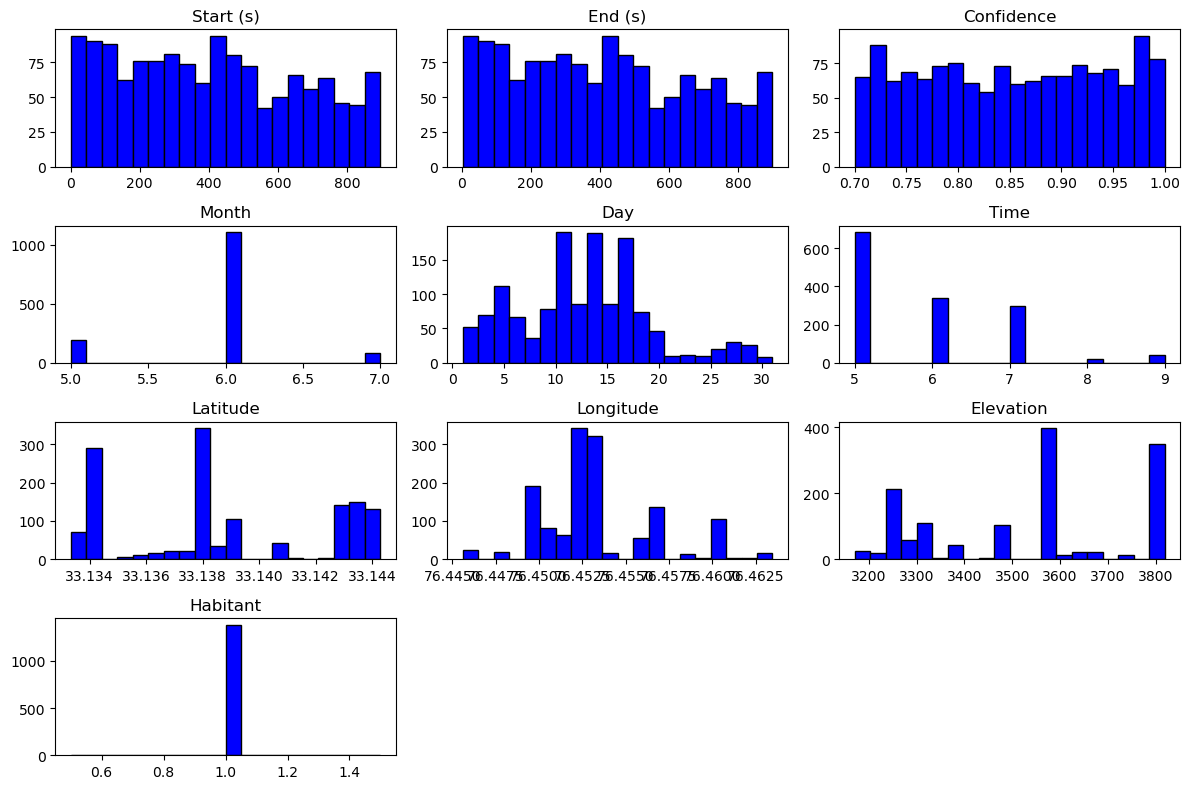

c:\Users\shang\Programs\anaconda3\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


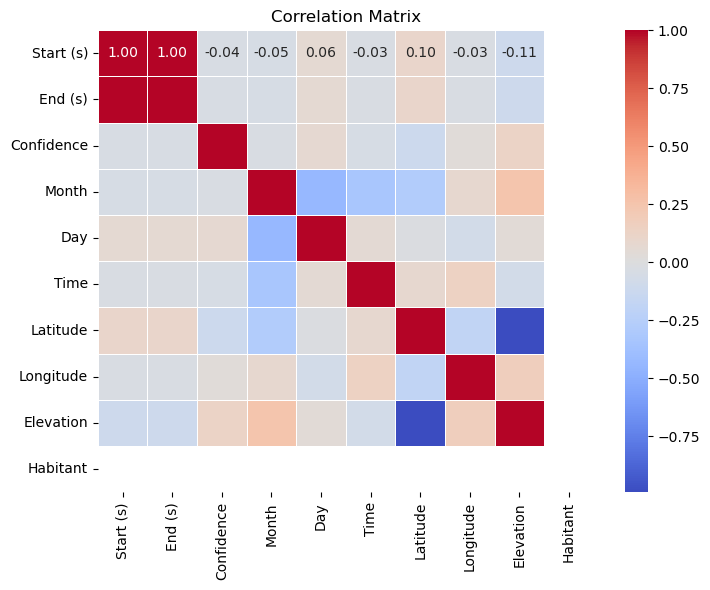


Checking for Multicollinearity (Correlation Threshold > 0.80):
High correlation pairs found:
 - End (s) and Start (s): Correlation = 1.00
 - Elevation and Latitude: Correlation = 0.99


,Start (s),End (s),Common name,Confidence,ID,Month,Day,Time,Latitude,Longitude,Elevation,Habitant,Temp_ID
0,357.0,360.0,hume's warbler,0.9889,psh10,6,4,6,33.135140,76.463139,3664,1,psh10_6_4_6_357.0_360.0
1,357.0,360.0,himalayan bluetail,0.7929,psh10,6,4,6,33.135140,76.463139,3664,1,psh10_6_4_6_357.0_360.0
2,414.0,417.0,himalayan bluetail,0.9378,psh10,6,4,6,33.135140,76.463139,3664,1,psh10_6_4_6_414.0_417.0
3,414.0,417.0,buff-barred warbler,0.8451,psh10,6,4,6,33.135140,76.463139,3664,1,psh10_6_4_6_414.0_417.0
4,486.0,489.0,hume's warbler,0.9941,psh10,6,4,6,33.135140,76.463139,3664,1,psh10_6_4_6_486.0_489.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1378,579.0,582.0,himalayan bluetail,0.7265,psm8,7,4,7,33.140866,76.449915,3370,1,psm8_7_4_7_579.0_582.0
1379,492.0,495.0,hume's warbler,0.8475,psm8,7,11,5,33.140866,76.449915,3370,1,psm8_7_11_5_492.0_495.0
1380,492.0,495.0,greenish warbler,0.7873,psm8,7,11,5,33.140866,76.449915,3370,1,psm8_7_11_5_492.0_495.0
1381,789.0,792.0,variegated laughingthrush,0.8647,psm9,6,2,7,33.141258,76.461078,3438,1,psm9_6_2_7_789.0_792.0


In [40]:
visual_data(df_group) 

In [41]:
explore_dataset(df_group)

Column: Start (s)
Unique values:
[357. 414. 486. 417. 591. 132.  48. 531. 876. 636. 264. 294.  30. 249.
 291. 513. 663. 201. 387. 492. 690. 729.  24.  84.  93. 153. 183. 198.
 231. 240. 267. 441. 510. 660. 156.  99. 684. 699. 720. 717. 114. 396.
 489. 576. 693. 456. 714.   3. 462. 681. 864. 411. 477. 870.  90. 186.
 270. 276. 288. 300. 303. 312. 363. 444. 450. 495.  54. 471. 117. 315.
 327. 339. 372. 384. 420. 429. 435. 549. 573. 858. 519.  18.  60.  81.
 324. 423. 594.  42. 120. 141. 483. 504. 543. 567. 585. 597.  36. 174.
 447. 453. 888. 330. 498. 507. 540. 603. 609. 807. 852. 873.  63. 831.
 837. 861.  15.  21.  33.  45.  57.  66.  72. 102. 147. 192. 219. 261.
 612. 669. 696. 894.  27. 879. 108. 207. 255. 765. 774. 732. 648. 702.
 783. 213. 225. 546. 360.  69. 438. 501. 642. 744. 762. 105. 780. 816.
 738. 234. 279. 246. 777. 756. 306. 522. 753. 285. 171. 723. 735. 237.
 348. 366. 402. 657. 228. 369. 135. 216. 336.  75.  39. 222. 252. 651.
 708. 129. 666. 828. 885. 891.  51.  78. 459

In [42]:
df_group['Common name'].value_counts()

Common name
hume's warbler                      439
himalayan bluetail                  348
western crowned warbler             177
variegated laughingthrush           144
tytler's leaf warbler                84
greenish warbler                     73
olive-backed pipit                   23
rufous-breasted accentor             16
himalayan monal                      16
common rosefinch                     12
slaty-blue flycatcher                11
buff-barred warbler                   7
large-billed leaf warbler             5
rock bunting                          4
himalayan white-browed rosefinch      4
eurasian kestrel                      4
blue-fronted redstart                 4
tickell's leaf warbler                3
coal tit                              3
rufous-naped tit                      3
blue whistling-thrush                 1
pink-browed rosefinch                 1
eurasian wren                         1
Name: count, dtype: int64

In [43]:
pairs = df_group.groupby('Temp_ID')['Common name'].apply(lambda x: tuple(sorted(x.unique())))


In [44]:
pairs.value_counts()

Common name
(himalayan bluetail, hume's warbler)                      319
(tytler's leaf warbler, western crowned warbler)           82
(variegated laughingthrush, western crowned warbler)       73
(greenish warbler, hume's warbler)                         48
(hume's warbler, variegated laughingthrush)                33
(olive-backed pipit, variegated laughingthrush)            21
(greenish warbler, himalayan bluetail)                     18
(hume's warbler, western crowned warbler)                  11
(himalayan monal, hume's warbler)                          11
(common rosefinch, hume's warbler)                          5
(slaty-blue flycatcher, variegated laughingthrush)          4
(rock bunting, rufous-breasted accentor)                    4
(buff-barred warbler, himalayan bluetail)                   4
(eurasian kestrel, himalayan white-browed rosefinch)        4
(rufous-breasted accentor, variegated laughingthrush)       4
(hume's warbler, slaty-blue flycatcher)                   

In [45]:
# Count the frequency of each unique pair
pair_counts = pairs.value_counts()
pairs_hume = pair_counts[[ "hume's warbler" in combo for combo in pair_counts.index ]]
print(pairs_hume)

Common name
(himalayan bluetail, hume's warbler)                      319
(greenish warbler, hume's warbler)                         48
(hume's warbler, variegated laughingthrush)                33
(hume's warbler, western crowned warbler)                  11
(himalayan monal, hume's warbler)                          11
(common rosefinch, hume's warbler)                          5
(hume's warbler, slaty-blue flycatcher)                     3
(hume's warbler, tickell's leaf warbler)                    3
(hume's warbler, large-billed leaf warbler)                 2
(buff-barred warbler, hume's warbler)                       2
(hume's warbler, pink-browed rosefinch)                     1
(greenish warbler, himalayan bluetail, hume's warbler)      1
Name: count, dtype: int64
